In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path
root_path = Path().resolve().parent.parent

sys.path.append(str(root_path))
from utils.eda import *
from utils.visualization import *

In [2]:
df = pd.read_csv("../data/weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
summary_stats(df)

SHAPE        : 145460 rows × 23 columns

── DTYPES ──
                 dtype  nunique      sample
Date            object     3436  2008-12-01
Location        object       49      Albury
MinTemp        float64      389        13.4
MaxTemp        float64      505        22.9
Rainfall       float64      681         0.6
Evaporation    float64      358         NaN
Sunshine       float64      145         NaN
WindGustDir     object       16           W
WindGustSpeed  float64       67        44.0
WindDir9am      object       16           W
WindDir3pm      object       16         WNW
WindSpeed9am   float64       43        20.0
WindSpeed3pm   float64       44        24.0
Humidity9am    float64      101        71.0
Humidity3pm    float64      101        22.0
Pressure9am    float64      546      1007.7
Pressure3pm    float64      549      1007.1
Cloud9am       float64       10         8.0
Cloud3pm       float64       10         NaN
Temp9am        float64      441        16.9
Temp3pm        float64

In [4]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 23)
               missing_count  missing_pct    dtype
Sunshine               69835        48.01  float64
Evaporation            62790        43.17  float64
Cloud3pm               59358        40.81  float64
Cloud9am               55888        38.42  float64
Pressure9am            15065        10.36  float64
Pressure3pm            15028        10.33  float64
WindDir9am             10566         7.26   object
WindGustDir            10326         7.10   object
WindGustSpeed          10263         7.06  float64
Humidity3pm             4507         3.10  float64
WindDir3pm              4228         2.91   object
Temp3pm                 3609         2.48  float64
RainTomorrow            3267         2.25   object
Rainfall                3261         2.24  float64
RainToday               3261         2.24   object
WindSpeed3pm            3062         2.11  float64
Humidity9am             2654         1.82  float64
Temp9am                 1767         1.21 

In [5]:
## distribusi
fitur_numeric = df.select_dtypes(include=np.number).columns.tolist()
fitur_categorical = df.select_dtypes(include=object).columns.tolist()

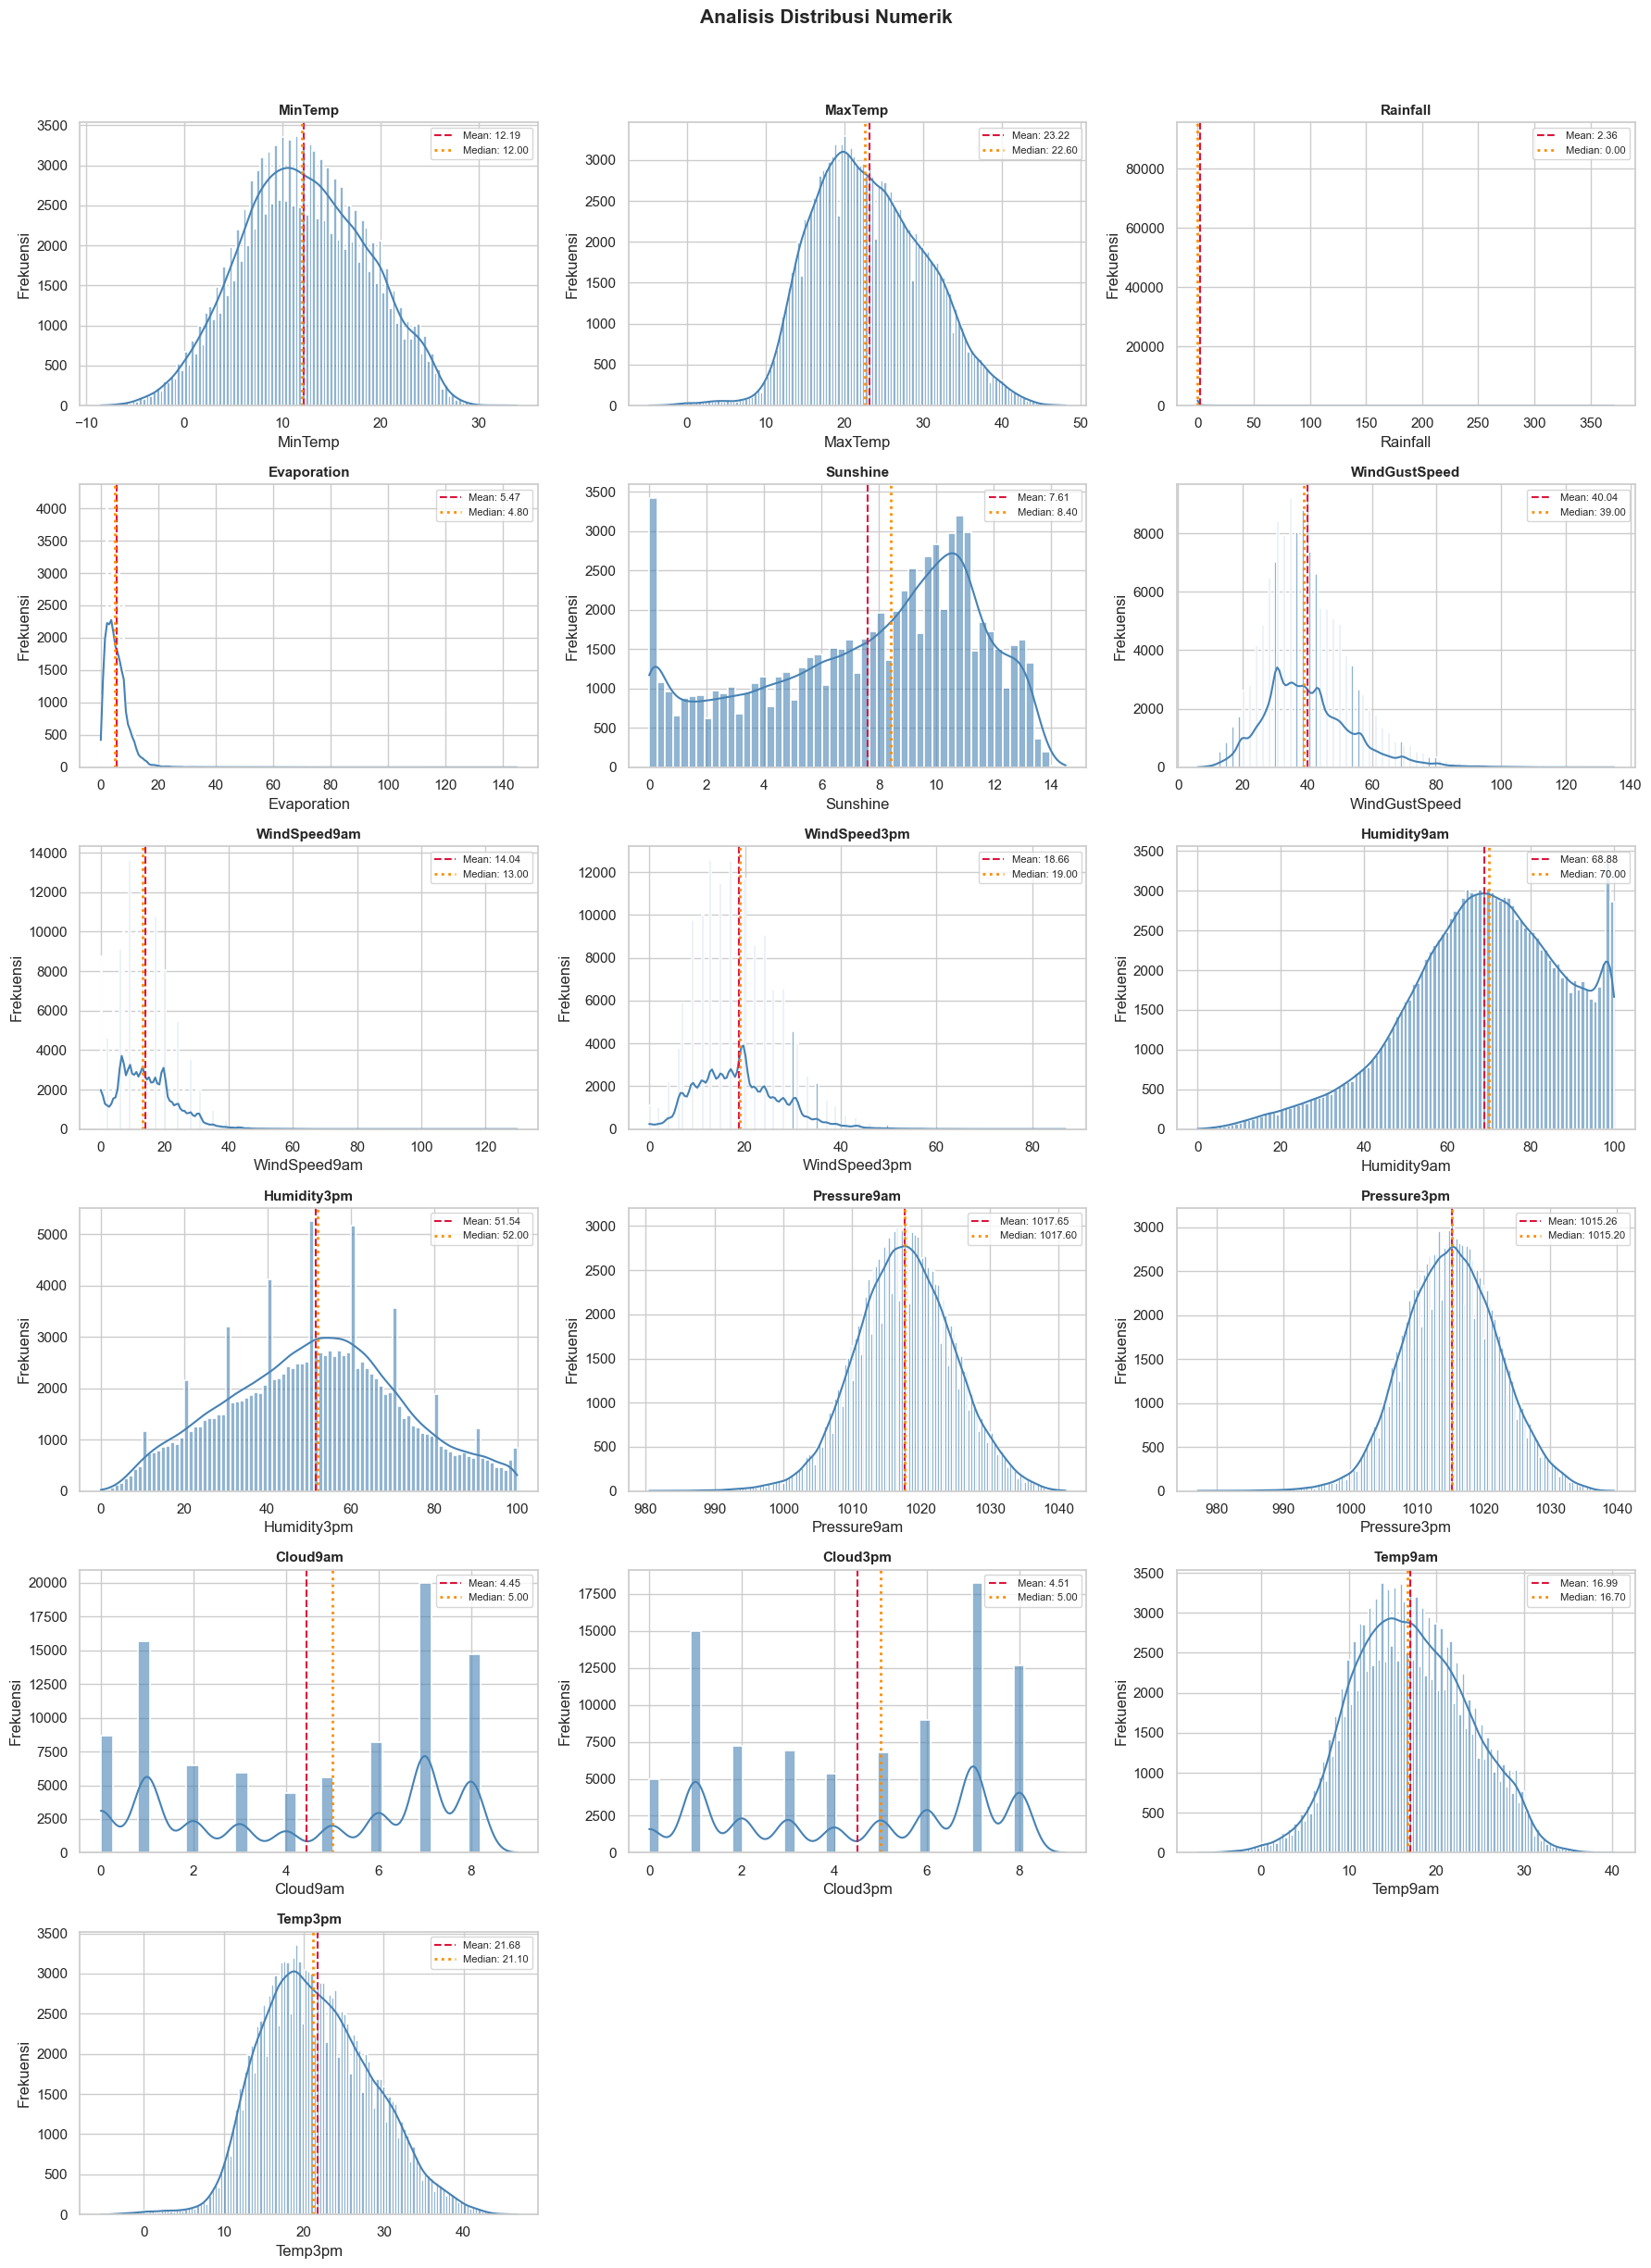

In [6]:
plot_distributions(df, fitur_numeric)

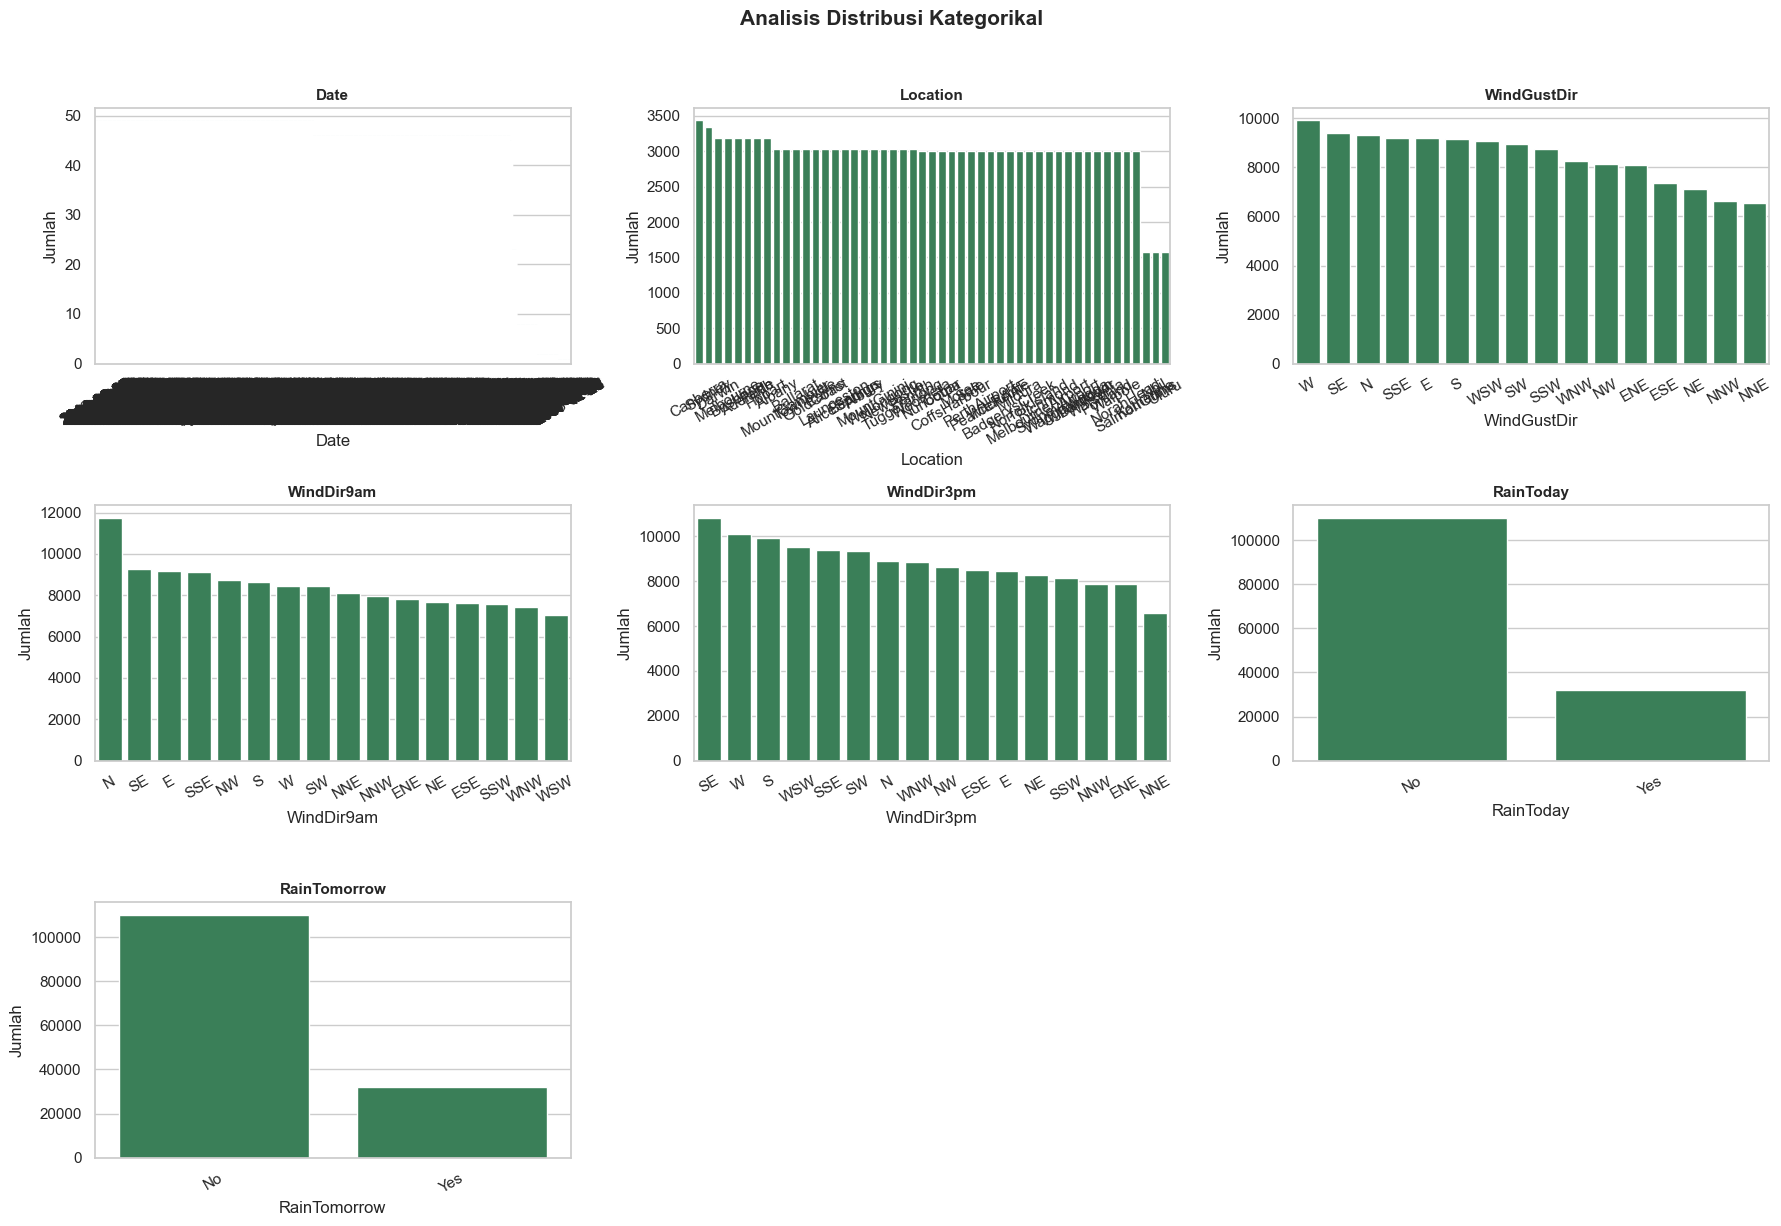

In [7]:
plot_distributions(df, fitur_categorical)

In [8]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
       column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
     Rainfall       25578         17.99         True        -1.20         2.00
WindGustSpeed        3092          2.29         True         5.50        73.50
 WindSpeed3pm        2523          1.77         True        -3.50        40.50
  Evaporation        1995          2.41         True        -4.60        14.60
 WindSpeed9am        1817          1.26         True       -11.00        37.00
  Humidity9am        1425          1.00         True        18.00       122.00
  Pressure9am        1191          0.91         True       998.65      1036.65
  Pressure3pm         919          0.70         True       996.00      1034.40
      Temp3pm         764          0.54         True         1.90        41.10
      MaxTemp         489          0.34         True         2.45        43.65
      Temp9am         262          0.18         True        -1.65        35.55
      MinTemp          

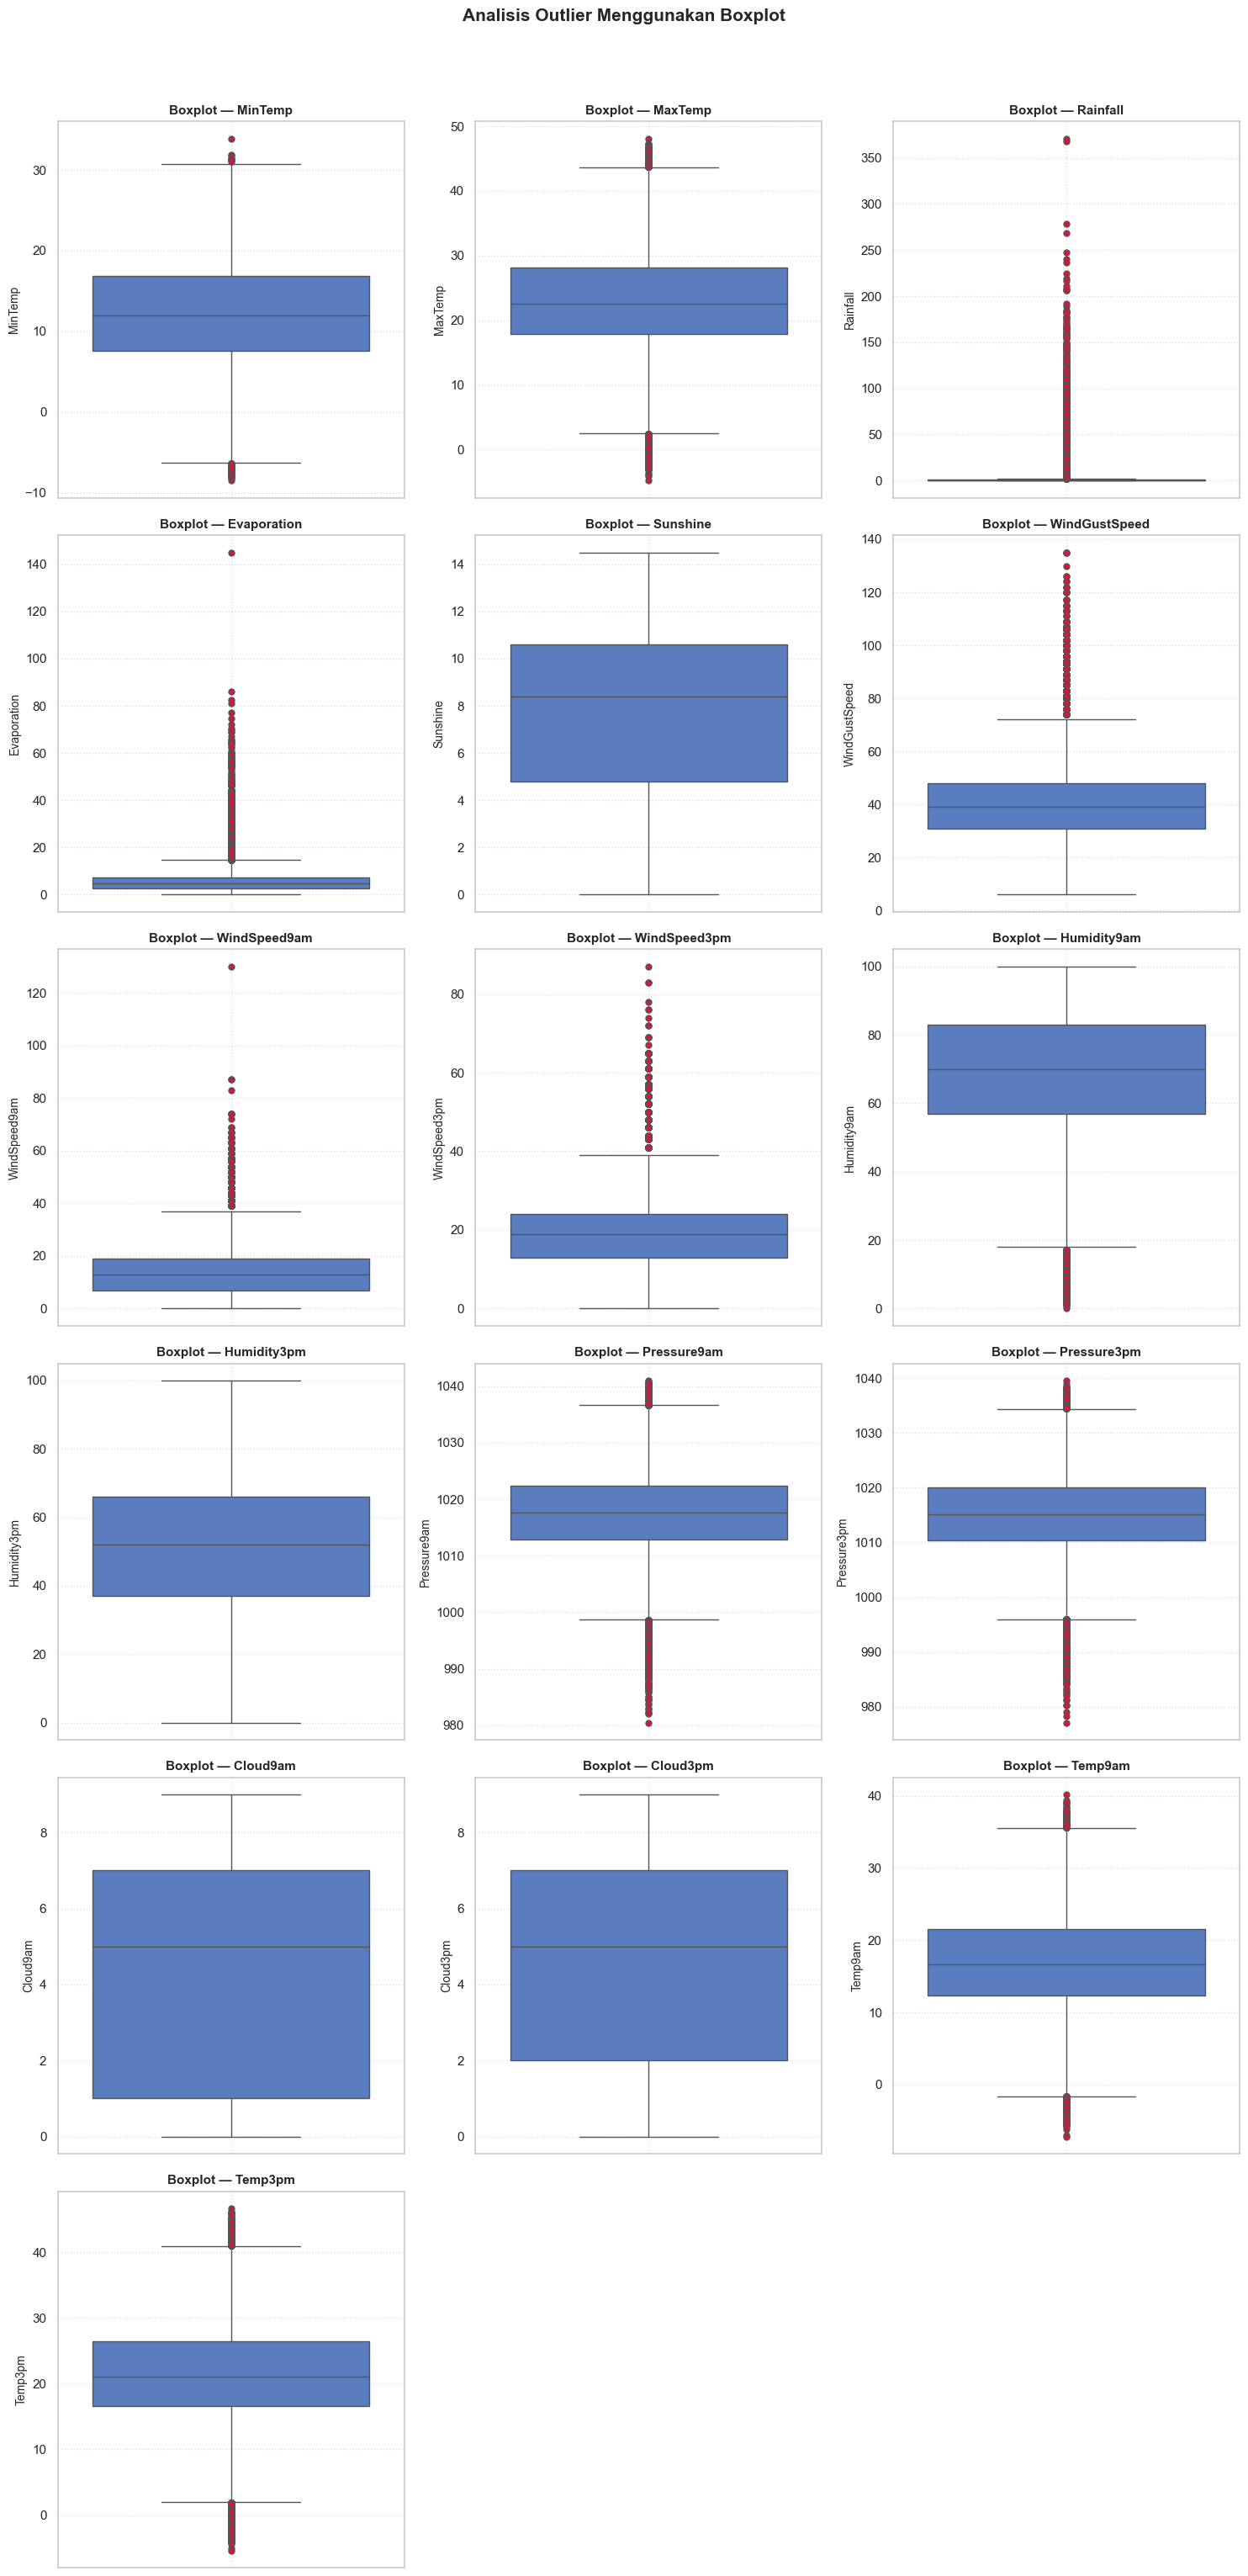

In [9]:
plot_boxplot(df, fitur_numeric)

In [10]:
class_balance(df, "RainTomorrow")

CLASS BALANCE — 'RainTomorrow'
               count    pct
RainTomorrow               
No            110316  77.58
Yes            31877  22.42

Imbalance ratio (max/min): 3.46x
⚠  Dataset tampak imbalanced (ratio > 3).


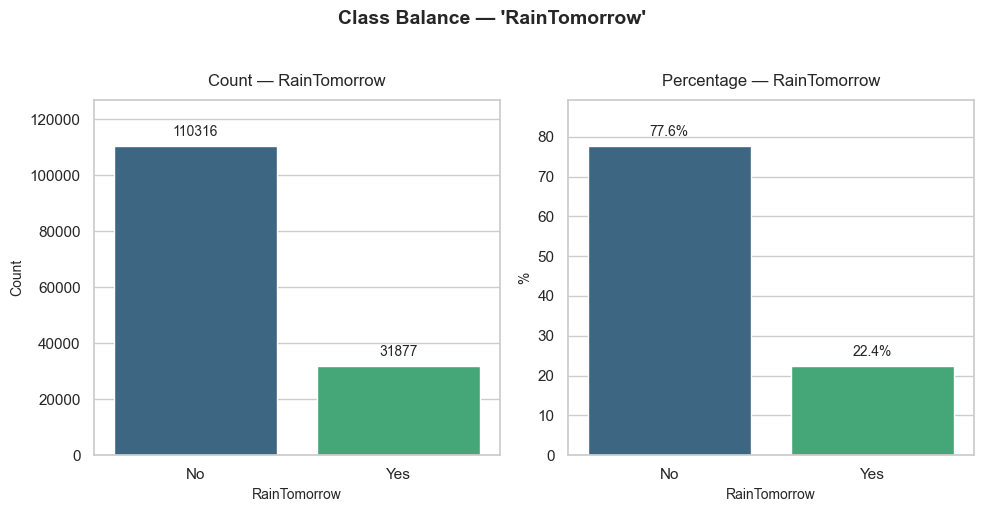

In [11]:
plot_class_balance(df, "RainTomorrow")

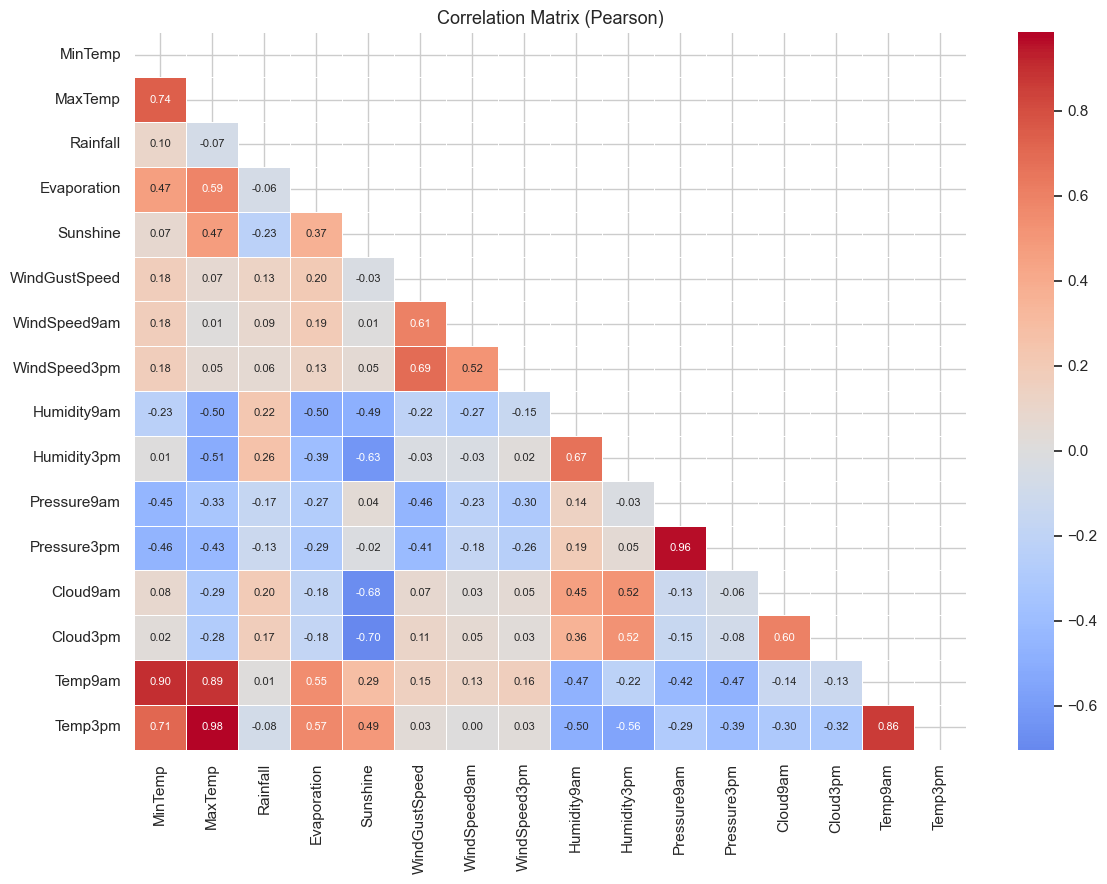

In [12]:
correlation_matrix(df)

## Profil dataset
- Ukuran dataset memiliki 145460 rows × 23 columns
- Data Target mengalami imbalance data. Dari visualisasi dan laporan statistik data kategorikal, distribusi kelas "No" jauh lebih mendominasi dibandingkan kelas "Yes". Kolom target ini juga memiliki data yang hilang sebanyak 3.267 baris (2.25%)
- Dataset terdiri dari fitur numerik `float64` dan fitur kategori `object`. Kolom `Date` bertipe object perlu dikonversi ke format jika ingin digunakan untuk time series

## Fitur yang harus di drop
- Sunshine: Kehilangan 69835 data 48.01%
- Evaporation: Kehilangan 62790 data 43.17%
- Cloud3pm: Kehilangan 59358 data 40.81% 
- Cloud9am: Kehilangan 55888 data 38.42%

## Fitur Numerik harus diimputasi median
- Pressure9am            15065        10.36  float64
- Pressure3pm            15028        10.33  float64
- WindGustSpeed          10263         7.06  float64
- Humidity3pm             4507         3.10  float64
- Temp3pm                 3609         2.48  float64
- Rainfall                3261         2.24  float64
- WindSpeed3pm            3062         2.11  float64
- Humidity9am             2654         1.82  float64
- Temp9am                 1767         1.21  float64
- WindSpeed9am            1767         1.21  float64
- MinTemp                 1485         1.02  float64
- MaxTemp                 1261         0.87  float64

## Fitur Kategori harus diimputasi modus
- WindDir9am             10566         7.26   object
- WindGustDir            10326         7.10   object
- WindDir3pm              4228         2.91   object
- RainToday               3261         2.24   object